# Table of Contents
- [Estimating & Minimising $HCl$ used for brine acidification](#estimating-minimising-hcl-used-for-brine-acidification)
  - [Why Acidification is required for feed brine to Electrolyser](#why-acidification-is-required-for-feed-brine-to-electrolyser)
    - [1. Chlorate Suppression](#1-chlorate-suppression)
    - [2. Oxygen Evolution Suppression](#2-oxygen-evolution-suppression)
  - [Analysing Library](#analysing-library)
  - [Working with Reaktoro](#working-with-reaktoro)
  - [Industrial Brine Properties](#industrial-brine-properties)
  - [Aqueous Concentration Concepts](#aqueous-concentration-concepts)
    - [Why "Adjust for 0.9 kgw"?](#why-adjust-for-09-kgw)
      - [The Visualization:](#the-visualization)
    - [Worked Examples](#worked-examples)
      - [1. Converting 0.8 g/L $Na_2CO_3$ to molality](#1-converting-08-gl-na_2co_3-to-molality)
      - [2. Converting NaCl (290 g/L) to Molality](#2-converting-nacl-290-gl-to-molality)
      - [3. Converting Impurities (ppb to molality)](#3-converting-impurities-ppb-to-molality)
      - [4. Converting pH 9 to OH-](#4-converting-ph-9-to-oh-)
      - [Summary Table](#summary-table)
  - [Translating Molality to Plant's Volumetric Flowrate](#translating-molality-to-plants-volumetric-flowrate)
    - [Part 1: `(50 * brine_density)`](#part-1-50-brine_density)
    - [Part 2: `(1.0 / brine.mass())`](#part-2-10-brinemass)
  - [Reaktoro Understands Temperature Effects on pH](#reaktoro-understands-temperature-effects-on-ph)
    - [Explaining Alkaline side of curves](#explaining-alkaline-side-of-curves)
      - [The Engineering Reality: Cooling Samples for pH Measurement](#the-engineering-reality-cooling-samples-for-ph-measurement)
    - [Explaining Acidic side of curves](#explaining-acidic-side-of-curves)
    - [The Paradox Resolved](#the-paradox-resolved)
  - [Reaktoro Understands pH Buffering](#reaktoro-understands-ph-buffering)
  - [Simulating Multiple Impurities Impact on Acid Consumption](#simulating-multiple-impurities-impact-on-acid-consumption)
    - [$pK_a$ is for ions only](#pk_a-is-for-ions-only)
      - [Carbonate System (Carbonic Acid, $H_2CO_3$)](#carbonate-system-carbonic-acid-h_2co_3)
      - [Sulfate System (Sulfuric Acid, $H_2SO_4$)](#sulfate-system-sulfuric-acid-h_2so_4)
  - [Henderson-Hasselbalch Equation](#henderson-hasselbalch-equation)
    - [Why Carbonate is a sponge for acid](#why-carbonate-is-a-sponge-for-acid)
      - [Step 1: Carbonate ($CO_3^{2-}$) to Bicarbonate ($HCO_3^-$)](#step-1-carbonate-co_32--to-bicarbonate-hco_3-)
      - [Step 2: Bicarbonate ($HCO_3^-$) to Carbonic Acid ($H_2CO_3$)](#step-2-bicarbonate-hco_3--to-carbonic-acid-h_2co_3)
    - [Why Sulphate didn't consumed acid](#why-sulphate-didnt-consumed-acid)
    - [First Engineering Rule of Thumb](#first-engineering-rule-of-thumb)
    - [Engineering Danger of having $pH$ close to $pK_a$](#engineering-danger-of-having-ph-close-to-pk_a)
    - [Second Engineering Rule of Thumb](#second-engineering-rule-of-thumb)
    - [Analyzing the Curves](#analyzing-the-curves)
      - [Revisiting pH Temperature Dependance](#revisiting-ph-temperature-dependance)

<a id="estimating-minimising-hcl-used-for-brine-acidification"></a>
# Estimating & Minimising $HCl$ used for brine acidification

The notebook simulates how quantity of acid dosage changes with different physical parameters (like temperature) and chemical parameters (like carbonate or sulphate impurities). $HCl$ acid is a high commodity item & minimising its usage economises your process.

Additionaly I compared two libraries `reaktoro` & `phreeqpython` for severely saline solutions. The comparison will be discussed in future however `phreeqpython` is designed for water treatment scenarios & showed its inability while handling concentrated brines.

<a id="why-acidification-is-required-for-feed-brine-to-electrolyser"></a>
## Why Acidification is required for feed brine to Electrolyser

Even with high-performance membranes, a small amount of hydroxide ($OH^-$) can back-migrate from the cathode into the anode compartment. This leakage or **Membrane Rejection Efficiency** exacerbates with the age of membranes the life cycle of which is ~4 years

<a id="1-chlorate-suppression"></a>
### 1. Chlorate Suppression
If the brine is near neutral or alkaline, the dissolved chlorine gas reacts with the water and leaked hydroxide to form **Hypochlorite ($OCl^-$)**:

$$Cl_2 + 2OH^- \rightarrow OCl^- + Cl^- + H_2O$$

At the high temperatures of the cell (80-90 °C), Hypochlorite quickly converts to Chlorate through two pathways:
*   **Chemical Pathway:** $3OCl^- \rightarrow ClO_3^- + 2Cl^-$
*   **Electrochemical Pathway:** Hypochlorite is oxidized directly at the anode:
    $$6OCl^- + 3H_2O \rightarrow 2ClO_3^- + 4Cl^- + 1.5O_2 + 6H^+ + 6e^-$$

By injecting HCl into the feed brine, you shift the chlorine hydrolysis equilibrium to the **left**:

$$Cl_2 + H_2O \rightleftharpoons HOCl + H^+ + Cl^-$$

Because the concentration of $H^+$ is kept high (low pH), the reaction is suppressed (Le Chatelier's Principle). 
*   **Outcome:** Chlorine remains as $Cl_2$ gas and exits the cell immediately.
*   **Benefit:** Without the $OCl^-$ intermediate, chlorate formation is blocked.

<a id="2-oxygen-evolution-suppression"></a>
### 2. Oxygen Evolution Suppression
The second major benefit of acidification is the suppression of oxygen ($O_2$) evolution, which improves chlorine gas purity. At the anode, two reactions compete for current:
*   **Chlorine Evolution (Desired):** $2Cl^- \rightarrow Cl_2 + 2e^-$
*   **Water Oxidation (Undesired):** $2H_2O \rightarrow O_2 + 4H^+ + 4e^-$

In [1]:
# import libraries and display OS / libraries versions
import reaktoro as rkt
import matplotlib.pyplot as plt
%load_ext watermark
%watermark -v -m -p reaktoro,PhreeqPython,matplotlib
print(f"PhreeqPython backend : /home/ukhan/miniforge3/envs/reaktoro/lib/libIPhreeqc.so.3.8.7 ")

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.12.0

reaktoro    : 2.13.0
PhreeqPython: 1.5.7
matplotlib  : 3.10.8

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.147-sun55iw3
Machine     : aarch64
Processor   : aarch64
CPU cores   : 8
Architecture: 64bit

PhreeqPython backend : /home/ukhan/miniforge3/envs/reaktoro/lib/libIPhreeqc.so.3.8.7 


<a id="analysing-library"></a>
## Analysing Library
Its a good practice what the `namespace` of library offers. Between cells `3` and `6` we use a simple one-liner code to get `classes` available to us & most importanly what `methods` each `class` offers. Callable `methods` in python are important to engineers; these generally hold properties or attributes like density, pH...

In [2]:
# One-liner to print only the Classes + Methods + Functions inside the 'rkt' namespace
print([name for name in dir(rkt) if callable(getattr(rkt, name)) and not name.startswith('_')])

['ActivityModel', 'ActivityModelArgs', 'ActivityModelDavies', 'ActivityModelDaviesParams', 'ActivityModelDebyeHuckel', 'ActivityModelDebyeHuckelKielland', 'ActivityModelDebyeHuckelLimitingLaw', 'ActivityModelDebyeHuckelPHREEQC', 'ActivityModelDebyeHuckelParams', 'ActivityModelDebyeHuckelWATEQ4F', 'ActivityModelDrummond', 'ActivityModelDrummondParams', 'ActivityModelDuanSun', 'ActivityModelExtendedUNIQUAC', 'ActivityModelHKF', 'ActivityModelIdealAqueous', 'ActivityModelIdealGas', 'ActivityModelIdealIonExchange', 'ActivityModelIdealSolution', 'ActivityModelIonExchange', 'ActivityModelIonExchangeGainesThomas', 'ActivityModelIonExchangeVanselow', 'ActivityModelParamsExtendedUNIQUAC', 'ActivityModelParamsPitzer', 'ActivityModelPengRobinson', 'ActivityModelPengRobinson76', 'ActivityModelPengRobinson78', 'ActivityModelPengRobinsonPHREEQC', 'ActivityModelPengRobinsonPhreeqc', 'ActivityModelPengRobinsonPhreeqcOriginal', 'ActivityModelPengRobinsonSoreideWhitson', 'ActivityModelPhreeqc', 'Activit

In [3]:
# One-liner to print only the Classes inside the 'rkt' namespace
print([name for name in dir(rkt) if isinstance(getattr(rkt, name), type)])

['ActivityModel', 'ActivityModelArgs', 'ActivityModelDaviesParams', 'ActivityModelDebyeHuckelParams', 'ActivityModelDrummondParams', 'ActivityModelParamsExtendedUNIQUAC', 'ActivityModelParamsPitzer', 'ActivityProps', 'ActivityPropsConstRef', 'ActivityPropsRef', 'AggregateState', 'AqueousMixture', 'AqueousMixtureState', 'AqueousPhase', 'AqueousProps', 'ChemicalFormula', 'ChemicalProps', 'ChemicalPropsPhase', 'ChemicalPropsPhaseConstRef', 'ChemicalPropsPhaseRef', 'ChemicalState', 'ChemicalSystem', 'CondensedPhase', 'CondensedPhases', 'ConstraintEquation', 'ControlVariableP', 'ControlVariableQ', 'CriticalProps', 'Data', 'Database', 'Element', 'ElementList', 'ElementalComposition', 'Elements', 'Embedded', 'EquationConstraint', 'EquationConstraintFn', 'EquationConstraints', 'EquilibriumConditions', 'EquilibriumDims', 'EquilibriumOptions', 'EquilibriumRestrictions', 'EquilibriumResult', 'EquilibriumSensitivity', 'EquilibriumSolver', 'EquilibriumSpecs', 'Exclude', 'FormationReaction', 'Gaseou

In [4]:
# One-liner to print only the Methods inside the 'rkt.Material' Class namespace
print([name for name in dir(rkt.Material) if callable(getattr(rkt.Material, name)) and not name.startswith('_')])

['add', 'addMaterialAmount', 'addMaterialMass', 'addSpeciesAmount', 'addSpeciesMass', 'addSubstanceAmount', 'addSubstanceMass', 'amount', 'charge', 'componentAmounts', 'elementAmounts', 'equilibrate', 'initialState', 'mass', 'molarMass', 'result', 'scale', 'scaleAmount', 'scaleMass', 'species', 'substances', 'system']


In [5]:
# One-liner to print only the Methods inside the 'rkt.ChemicalProps' Class namespace
print([name for name in dir(rkt.ChemicalProps) if callable(getattr(rkt.ChemicalProps, name)) and not name.startswith('_')])

['amount', 'charge', 'chargeAmongSpecies', 'chargeInPhase', 'componentAmounts', 'componentAmountsAmongSpecies', 'componentAmountsInPhase', 'density', 'elementAmount', 'elementAmountAmongSpecies', 'elementAmountInPhase', 'elementAmounts', 'elementAmountsAmongSpecies', 'elementAmountsInPhase', 'elementMass', 'elementMassAmongSpecies', 'elementMassInPhase', 'enthalpy', 'entropy', 'gibbsEnergy', 'heatCapacityConstP', 'heatCapacityConstV', 'helmholtzEnergy', 'indicesPhasesWithFluidState', 'indicesPhasesWithSolidState', 'indicesPhasesWithState', 'indicesPhasesWithStates', 'indicesSpeciesInPhasesWithFluidState', 'indicesSpeciesInPhasesWithSolidState', 'indicesSpeciesInPhasesWithState', 'indicesSpeciesInPhasesWithStates', 'internalEnergy', 'mass', 'molarEnthalpy', 'molarEntropy', 'molarGibbsEnergy', 'molarHeatCapacityConstP', 'molarHeatCapacityConstV', 'molarHelmholtzEnergy', 'molarInternalEnergy', 'molarVolume', 'molarVolumeP', 'molarVolumeT', 'output', 'phaseProps', 'pressure', 'reactionRate

<a id="working-with-reaktoro"></a>
## Working with Reaktoro
Between cells `6` and `8` a database is loaded which stores relevant data for many ionic species. Then `.Material` `class` is used to create an `object` called brine and finally `.equilibrate` `method` is used to calculate all properties of the brine.

In this example a $0.5M$ brine is defined either using full compound names or using ionic species. Latter being a preferable method. `.speciate` `method` will automatically identify from the list of elements possible ionic species that can occur at equilibrium at user defined temperature & pressure. 

In [6]:
# Reaktoro: Setup the Database and System
db = rkt.PhreeqcDatabase("phreeqc.dat")
solution = rkt.AqueousPhase(rkt.speciate("H O Na Cl"))
system = rkt.ChemicalSystem(db, solution)

In [7]:
# Defining Material using compounds
brine = rkt.Material(system)
brine.add("H2O", 1.0, "kg")
brine.add("NaCl", 0.5, "mol")

# Equilibrate
state = brine.equilibrate(25, "celsius", 1, "atm")

print("Success! Material defined using compounds:")
print(state)

Success! Material defined using compounds:


+-----------------+-------------+------+
| Property        |       Value | Unit |
+-----------------+-------------+------+
| Temperature     |    298.1500 |    K |
| Pressure        |      1.0132 |  bar |
| Charge:         | -1.3501e-16 |  mol |
| Element Amount: |             |      |
| :: H            |  1.1101e+02 |  mol |
| :: O            |  5.5506e+01 |  mol |
| :: Na           |  5.0000e-01 |  mol |
| :: Cl           |  5.0000e-01 |  mol |
| Species Amount: |             |      |
| :: H+           |  9.9704e-08 |  mol |
| :: H2O          |  5.5506e+01 |  mol |
| :: Cl-          |  5.0000e-01 |  mol |
| :: H2           |  1.0000e-16 |  mol |
| :: Na+          |  5.0000e-01 |  mol |
| :: OH-          |  9.9704e-08 |  mol |
| :: NaOH         |  1.0000e-16 |  mol |
| :: O2           |  1.0000e-16 |  mol |
+-----------------+-------------+------+

In [8]:
# Alternatively defining Material using individual ions
brine_ions = rkt.Material(system)
brine_ions.add("H2O", 1.0, "kg")
brine_ions.add("Na+", 0.5, "mol")
brine_ions.add("Cl-", 0.5, "mol")

# Equilibrate
state_ions = brine_ions.equilibrate(25, "celsius", 1, "atm")

print("Success! Material defined using ions:")
print(state_ions)

Success! Material defined using ions:
+-----------------+-------------+------+
| Property        |       Value | Unit |
+-----------------+-------------+------+
| Temperature     |    298.1500 |    K |
| Pressure        |      1.0132 |  bar |
| Charge:         | -1.3501e-16 |  mol |
| Element Amount: |             |      |
| :: H            |  1.1101e+02 |  mol |
| :: O            |  5.5506e+01 |  mol |
| :: Na           |  5.0000e-01 |  mol |
| :: Cl           |  5.0000e-01 |  mol |
| Species Amount: |             |      |
| :: H+           |  9.9704e-08 |  mol |
| :: H2O          |  5.5506e+01 |  mol |
| :: Cl-          |  5.0000e-01 |  mol |
| :: H2           |  1.0000e-16 |  mol |
| :: Na+          |  5.0000e-01 |  mol |
| :: OH-          |  9.9704e-08 |  mol |
| :: NaOH         |  1.0000e-16 |  mol |
| :: O2           |  1.0000e-16 |  mol |
+-----------------+-------------+------+


<a id="industrial-brine-properties"></a>
## Industrial Brine Properties

| **Property Type**  | **Parameter**       | **Value**       |
|---------------------|---------------------|-----------------|
| **Chemical Properties** | NaCl concentration  | 290 g/L         |
|                     | pH (initial)                  | 9               |
|                     | pH (target)                  | 3               |
|                     | Ca²⁺ concentration  | 8 ppb           |
|                     | Mg²⁺ concentration  | 2 ppb           |
|                     | Na₂CO₃ concentration | 0.8 g/L        |
|                     | Na₂SO₄ concentration | 10 g/L         |
| **Physical Properties** | Flow rate         | 50 m³/hr        |
|                     | Temperature         | 75°C            |
|                     | Pressure            | 2 atm           |


<a id="aqueous-concentration-concepts"></a>
## Aqueous Concentration Concepts

Recall that
- **Molarity (M)** is volume-based, **moles of solute per liter of solution**.
- If we used **moles per kg of water (kgw)**, it would be **molality (m)**, not molarity.
- If we used **moles per kg of solution**, it would be a **mass-based concentration**

<a id="why-adjust-for-09-kgw"></a>
### Why "Adjust for 0.9 kgw"?
This is the most common mistake made when moving from the lab (g/L) to a simulator like Reaktoro. 

The definition of **Molality** (which Reaktoro uses) is:
$$\text{Moles of Salt} \div \mathbf{1.0\text{ kg of Water}}$$
The recipe of our brine is based on 1 kg of pure water solvent ($kgw$).
However, in our 1-Liter bottle of brine:
1.  The total bottle weighs **1.19 kg** (1,190 grams).
2.  Inside that bottle, we have **290 grams of salt**.
3.  Therefore, we only have **900 grams of water** ($1190 - 290 = 900$).

If we just put the moles into the simulator without adjusting, the simulator thinks we have 1.0 kg of water. But we actually have less (0.9 kg). To find out how much salt would be in a full 1.0 kg of water to keep the ratio the same, we divide by 0.9.

<a id="the-visualization"></a>
#### The Visualization:
*   **Option A (No adjustment):** We put 4.96 moles of salt into **1000g** of water. (This is too weak).
*   **Option B (Adjusted):** We put 4.96 moles of salt into **900g** of water. (This matches our 290 g/L lab sample).

To tell the simulator Option B, we mathematically "scale it up" to the 1kg water standard:
$$4.962\text{ moles} \div 0.9\text{ kgw} = \mathbf{5.513\text{ mol/kgw}}$$

<a id="worked-examples"></a>
### Worked Examples
<a id="1-converting-08-gl-na_2co_3-to-molality"></a>
#### 1. Converting 0.8 g/L $Na_2CO_3$ to molality
Using the exact same logic, we can convert the carbonate addition:
1.  **Calculate Moles per Liter of Solution:**
    $$0.8\text{ g} \div 105.99\text{ g/mol} = \mathbf{0.007548\text{ moles (per Liter)}}$$
2.  **Adjust for the Water Mass (The 0.9 Factor):**
    Because 1 Liter of 290 g/L NaCl brine only contains **0.9 kg of water**, we must scale it up to find the true molality (moles per 1.0 kg of water):
    $$0.007548\text{ moles} \div 0.9\text{ kgw} = \mathbf{0.008387\text{ mol/kgw}}$$
    This translates directly to the code: `brine.add("Na2CO3", 0.008387, "mol")`

<a id="2-converting-nacl-290-gl-to-molality"></a>
#### 2. Converting NaCl (290 g/L) to Molality
Reaktoro works in **molality** (moles per 1.0 kg of water), but you gave me **concentration** (grams per 1.0 Liter of solution).

* **Step A (Density):** A 290 g/L NaCl brine has a physical density of approximately **1.19 kg/L**. 
* **Step B (Total Mass):** Therefore, 1 Liter of your brine weighs **1,190 grams**.
* **Step C (Water Mass):** If 290 grams of that is salt, the remaining mass is water:
  $$1,190\text{ g (Total)} - 290\text{ g (Salt)} = 900\text{ g of water (0.9 kgw)}$$
* **Step D (Moles):** Moles of NaCl = $290\text{ g} / 58.44\text{ g/mol} = \mathbf{4.962\text{ mol}}$
* **Step E (Molality):** To get the amount per 1.0 kg of water:
  $$4.962\text{ mol} / 0.9\text{ kgw} = \mathbf{5.513\text{ mol/kgw}}$$

<a id="3-converting-impurities-ppb-to-molality"></a>
#### 3. Converting Impurities (ppb to molality)
**ppb** (parts per billion) means micrograms ($\mu\text{g}$) of impurity per kilogram of total solution.

* **For Calcium (8 ppb):**
    * Mass = $8 \times 10^{-6}\text{ grams}$ per kg of solution.
    * Moles per kg solution = $(8 \times 10^{-6}\text{ g}) / 40.08\text{ g/mol} = 1.996 \times 10^{-7}\text{ mol}$.
    * Adjusting for water mass ($0.9\text{ kgw}$): $1.996 \times 10^{-7} / 0.9 = \mathbf{2.22 \times 10^{-7}\text{ mol/kgw}}$.

* **For Magnesium (2 ppb):**
    * Mass = $2 \times 10^{-6}\text{ grams}$ per kg of solution.
    * Moles per kg solution = $(2 \times 10^{-6}\text{ g}) / 24.31\text{ g/mol} = 8.22 \times 10^{-8}\text{ mol}$.
    * Adjusting for water mass ($0.9\text{ kgw}$): $8.22 \times 10^{-8} / 0.9 = \mathbf{9.14 \times 10^{-8}\text{ mol/kgw}}$.

<a id="4-converting-ph-9-to-oh-"></a>
#### 4. Converting pH 9 to OH-
Since pH is the negative log of $H^+$ activity, and we are in an alkaline range (pH 9):
* $pH + pOH = 14$
* $9 + pOH = 14 \implies pOH = 5$
* $[OH^-] = 10^{-pOH} = 10^{-5} = \mathbf{0.00001\text{ mol/kgw}}$

<a id="summary-table"></a>
#### Summary Table

| Parameter | Input Value | Calculation | Value (mol/kgw) |
| :--- | :--- | :--- | :--- |
| **NaCl** | 290 g/L | $(290 / 58.44) / 0.9$ | `5.513` |
| **Na₂CO₃** | 0.8 g/L | $(0.8 / 105.99) / 0.9$ | `0.008387` |
| **Calcium** | 8 ppb | $(8\text{e-}6 / 40.08) / 0.9$ | `2.22e-7` |
| **Magnesium** | 2 ppb | $(2\text{e-}6 / 24.31) / 0.9$ | `9.14e-8` |
| **pH** | 9 | $10^{-(14-9)}$ | `1e-5` |

<a id="translating-molality-to-plants-volumetric-flowrate"></a>
## Translating Molality to Plant's Volumetric Flowrate

This is why the **`Material`** class is so powerful—once these base ratios are defined for 1 kg of water, we can easily scale them to our **50 m³/hr** plant flow. In chemical simulations involving high-salinity brines, it is crucial to accurately bridge the physical flow rate of a plant ($m^3/hr$) with the molality-based calculations of the simulator (moles per kg of water, or $kgw$).

This is perfectly captured in the following code snippet:
```
total_kgw_hr = (50 * brine_density) * (1.0 / brine.mass())
```
<a id="part-1-50-brine_density"></a>
### Part 1: `(50 * brine_density)`
**Purpose: Calculate the total mass of the fluid flowing through the pipe.**
*   **`50`**: The plant's volumetric flow rate in **m³/hr**.
*   **`brine_density`**: The physical weight of the fluid per cubic meter (**kg/m³**).
*   **The Math:** Volume $\times$ Density = **Total mass flow rate** (kg/hr).
*   *Example:* If the brine density is $1200\text{ kg/m}^3$, then $50 \times 1200 = 60,000 \text{ kg/hr}$. This represents the combined weight of the water, dissolved salts, and all impurities flowing every hour.

<a id="part-2-10-brinemass"></a>
### Part 2: `(1.0 / brine.mass())`
**Purpose: Calculate the fraction of that flow that is actually water.**
In the simulator, your `brine` recipe is built around exactly **1.0 kg of water** plus various amounts of salts and ions. 
*   **`1.0`**: The mass of the pure water solvent in your recipe ($kgw$).
*   **`brine.mass()`**: In Reaktoro, this method returns the total mass of the material **in kilograms (kg)** as a standard Python float. For our highly concentrated ~5.5 molal brine, adding the dissolved Sodium, Chloride, Carbonate, and Sulfate ions to the 1.0 kg of water yields a total `brine.mass()` of exactly **`1.334 kg`**.
*   **The Math:** By dividing the mass of the pure water by the total mass of the recipe, you get the **water mass fraction**.
*   *Example:* $1.0 \div 1.334 = \mathbf{0.7495}$. This tells the math: *"Exactly 74.95% of the total mass flowing through this pipe is actually water."*



Starting Titrations across multiple temperatures...



--- RESULTS (25 °C) ---
Brine Density: 1208.56 kg/m3
Acid required: 0.57 mmol/kgw
Industrial HCl (33%) flow: 2.50 L/hr



--- RESULTS (35 °C) ---
Brine Density: 1201.36 kg/m3
Acid required: 0.60 mmol/kgw
Industrial HCl (33%) flow: 2.60 L/hr



--- RESULTS (45 °C) ---
Brine Density: 1194.97 kg/m3
Acid required: 0.62 mmol/kgw
Industrial HCl (33%) flow: 2.69 L/hr



--- RESULTS (55 °C) ---
Brine Density: 1189.09 kg/m3
Acid required: 0.65 mmol/kgw
Industrial HCl (33%) flow: 2.78 L/hr



--- RESULTS (65 °C) ---
Brine Density: 1183.58 kg/m3
Acid required: 0.67 mmol/kgw
Industrial HCl (33%) flow: 2.88 L/hr



--- RESULTS (75 °C) ---
Brine Density: 1178.36 kg/m3
Acid required: 0.72 mmol/kgw
Industrial HCl (33%) flow: 3.08 L/hr


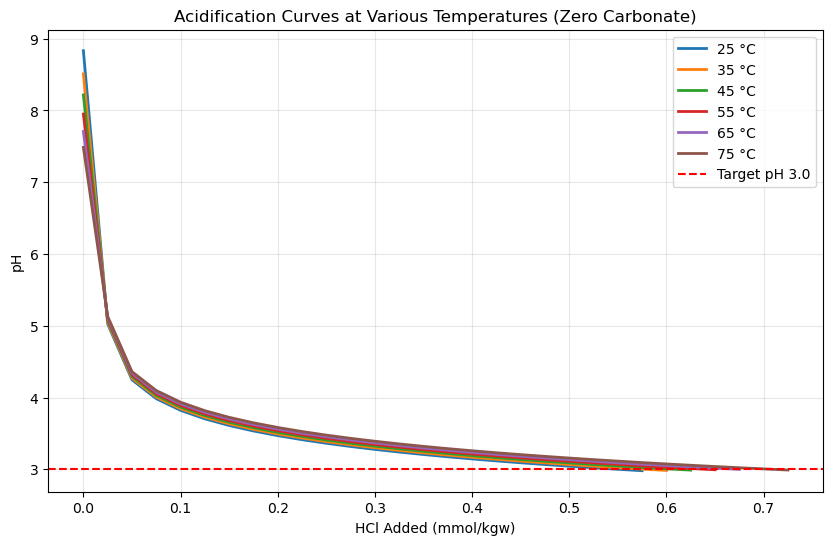

In [9]:
# --- BRINE ACIDIFICATION SIMULATION ZERO Carbonate (Multiple Temperatures) ---

# 1. Setup the System
db = rkt.PhreeqcDatabase("phreeqc.dat")
system = rkt.ChemicalSystem(db, 
    rkt.AqueousPhase(rkt.speciate("H O Na Cl Ca Mg")).set(rkt.ActivityModelPitzer())
)

# 2. Define the Base Brine
brine = rkt.Material(system)
brine.add("H2O", 1.0, "kg")
brine.add("Na+", 5.513, "mol")
brine.add("Cl-", 5.513, "mol")
brine.add("Ca+2", 2.22e-7, "mol")
brine.add("Mg+2", 9.14e-8, "mol")
brine.add("OH-", 1e-5, "mol")

# 3. Define Acid (HCl)
acid = rkt.Material(system)
acid.add("H+", 1.0, "mol")
acid.add("Cl-", 1.0, "mol")

# 4. Temperature Loop
temperatures = range(25, 76, 10)
results = {}

print("Starting Titrations across multiple temperatures...")

for T in temperatures:
    hcl_amount = 0.0
    step = 0.000025 
    
    # Equilibrate the initial brine at the target T and P to get the starting pH
    state_initial = brine.equilibrate(T, "celsius", 2, "atm")
    current_ph = rkt.AqueousProps(state_initial).pH()
    
    x_acid, y_ph = [0.0], [current_ph]
    
    while current_ph > 3.0:
        hcl_amount += step
        mixture = brine + acid(hcl_amount, "mol")
        state = mixture.equilibrate(T, "celsius", 2, "atm")
        current_ph = rkt.AqueousProps(state).pH()
        x_acid.append(hcl_amount * 1000)
        y_ph.append(current_ph)
        
    results[T] = (x_acid, y_ph)
    
    # Density & Precise Plant Flow Calculation
    props = rkt.ChemicalProps(state)
    brine_density = props.density()
    total_kgw_hr = (50 * brine_density) * (1.0 / brine.mass())
    total_hcl_mol_hr = hcl_amount * total_kgw_hr
    kg_industrial_hcl_hr = (total_hcl_mol_hr * 36.46) / 1000 / 0.33
    
    print(f"\n--- RESULTS ({T} °C) ---")
    print(f"Brine Density: {brine_density:.2f} kg/m3")
    print(f"Acid required: {hcl_amount*1000:.2f} mmol/kgw")
    print(f"Industrial HCl (33%) flow: {kg_industrial_hcl_hr/1.16:.2f} L/hr")

# 5. Plotting
plt.figure(figsize=(10, 6))
for T in temperatures:
    x_acid, y_ph = results[T]
    plt.plot(x_acid, y_ph, marker='', linewidth=2, label=f"{T} °C")

plt.axhline(y=3.0, color='red', linestyle='--', label="Target pH 3.0")
plt.title("Acidification Curves at Various Temperatures (Zero Carbonate)")
plt.xlabel("HCl Added (mmol/kgw)")
plt.ylabel("pH")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Starting Titrations across multiple temperatures (Carbonate Buffer)...



--- RESULTS (25 °C) ---
Brine Density: 1209.14 kg/m3
Acid required: 34.25 mmol/kgw
Industrial HCl (33%) flow: 149.06 L/hr



--- RESULTS (35 °C) ---
Brine Density: 1201.93 kg/m3
Acid required: 34.25 mmol/kgw
Industrial HCl (33%) flow: 148.17 L/hr



--- RESULTS (45 °C) ---
Brine Density: 1195.52 kg/m3
Acid required: 34.25 mmol/kgw
Industrial HCl (33%) flow: 147.38 L/hr



--- RESULTS (55 °C) ---
Brine Density: 1189.64 kg/m3
Acid required: 34.25 mmol/kgw
Industrial HCl (33%) flow: 146.66 L/hr



--- RESULTS (65 °C) ---
Brine Density: 1184.12 kg/m3
Acid required: 34.25 mmol/kgw
Industrial HCl (33%) flow: 145.98 L/hr



--- RESULTS (75 °C) ---
Brine Density: 1178.91 kg/m3
Acid required: 34.25 mmol/kgw
Industrial HCl (33%) flow: 145.33 L/hr


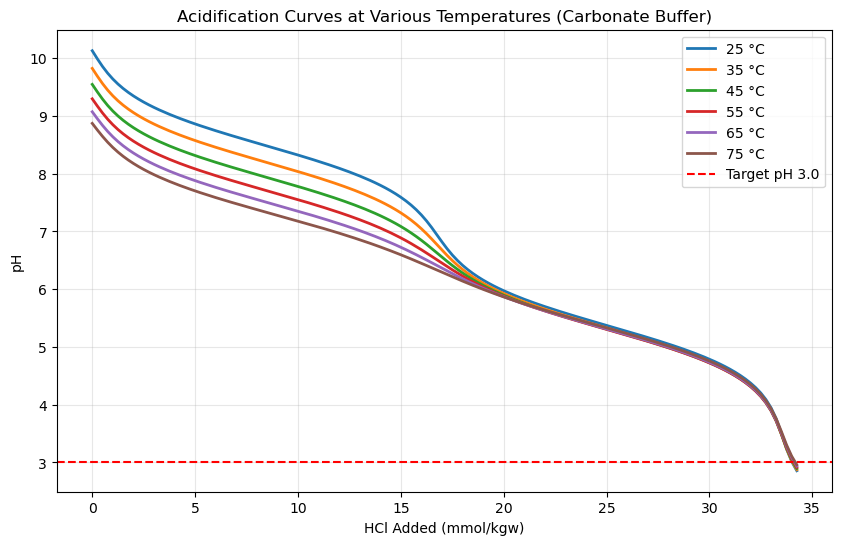

In [10]:
# --- BRINE ACIDIFICATION SIMULATION Carbonate Buffer (Multiple Temperatures) ---

# 1. Setup the System
db = rkt.PhreeqcDatabase("phreeqc.dat")
system = rkt.ChemicalSystem(db, 
    rkt.AqueousPhase(rkt.speciate("H O Na Cl Ca Mg C")).set(rkt.ActivityModelPitzer())
)

# 2. Define the Base Brine
brine = rkt.Material(system)
brine.add("H2O", 1.0, "kg")
brine.add("Na+", 5.513, "mol")
brine.add("Cl-", 5.513, "mol")
brine.add("Ca+2", 2.22e-7, "mol")
brine.add("Mg+2", 9.14e-8, "mol")
brine.add("OH-", 1e-5, "mol")
brine.add("Na2CO3", 0.008387, "mol") # 0.8 g/L Na2CO3 added

# 3. Define Acid (HCl)
acid = rkt.Material(system)
acid.add("H+", 1.0, "mol")
acid.add("Cl-", 1.0, "mol")

# 4. Temperature Loop
temperatures = range(25, 76, 10)
results = {}

print("Starting Titrations across multiple temperatures (Carbonate Buffer)...")

for T in temperatures:
    hcl_amount = 0.0
    step = 0.00025 # Step of 0.25 mmol
    
    # Equilibrate the initial brine at the target T and P to get the starting pH
    state_initial = brine.equilibrate(T, "celsius", 2, "atm")
    current_ph = rkt.AqueousProps(state_initial).pH()
    
    x_acid, y_ph = [0.0], [current_ph]
    
    while current_ph > 3.0:
        hcl_amount += step
        mixture = brine + acid(hcl_amount, "mol")
        state = mixture.equilibrate(T, "celsius", 2, "atm")
        current_ph = rkt.AqueousProps(state).pH()
        x_acid.append(hcl_amount * 1000)
        y_ph.append(current_ph)
        
    results[T] = (x_acid, y_ph)
    
    # Density & Precise Plant Flow Calculation
    props = rkt.ChemicalProps(state)
    brine_density = props.density()
    total_kgw_hr = (50 * brine_density) * (1.0 / brine.mass())
    total_hcl_mol_hr = hcl_amount * total_kgw_hr
    kg_industrial_hcl_hr = (total_hcl_mol_hr * 36.46) / 1000 / 0.33
    
    print(f"\n--- RESULTS ({T} °C) ---")
    print(f"Brine Density: {brine_density:.2f} kg/m3")
    print(f"Acid required: {hcl_amount*1000:.2f} mmol/kgw")
    print(f"Industrial HCl (33%) flow: {kg_industrial_hcl_hr/1.16:.2f} L/hr")

# 5. Plotting
plt.figure(figsize=(10, 6))
for T in temperatures:
    x_acid, y_ph = results[T]
    plt.plot(x_acid, y_ph, marker='', linewidth=2, label=f"{T} °C")

plt.axhline(y=3.0, color='red', linestyle='--', label="Target pH 3.0")
plt.title("Acidification Curves at Various Temperatures (Carbonate Buffer)")
plt.xlabel("HCl Added (mmol/kgw)")
plt.ylabel("pH")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Starting High-Resolution Titrations (Zooming in near pH 3.0)...


Finished at 25 °C.


Finished at 45 °C.


Finished at 65 °C.


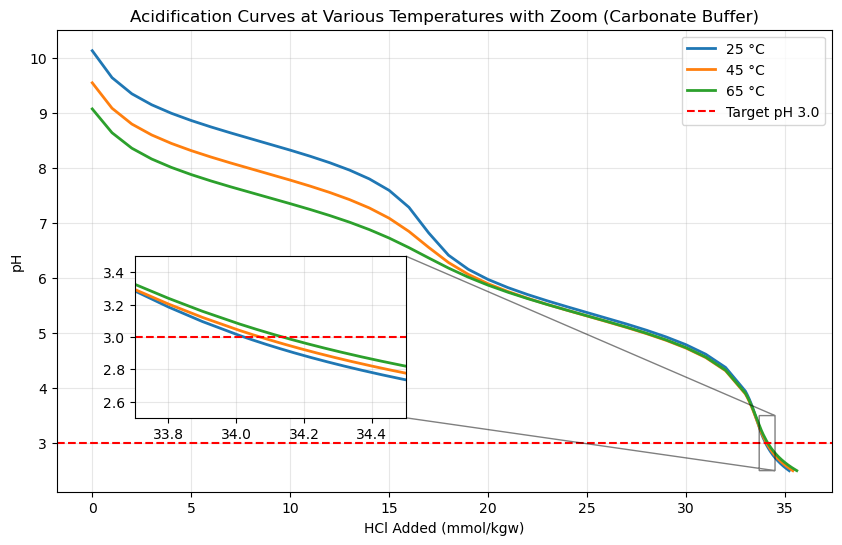

In [11]:
# 1. Setup the System
db = rkt.PhreeqcDatabase("phreeqc.dat")
system = rkt.ChemicalSystem(db, 
    rkt.AqueousPhase(rkt.speciate("H O Na Cl Ca Mg C")).set(rkt.ActivityModelPitzer())
)

# 2. Define the Base Brine
brine = rkt.Material(system)
brine.add("H2O", 1.0, "kg")
brine.add("Na+", 5.513, "mol")
brine.add("Cl-", 5.513, "mol")
brine.add("Ca+2", 2.22e-7, "mol")
brine.add("Mg+2", 9.14e-8, "mol")
brine.add("OH-", 1e-5, "mol")
brine.add("Na2CO3", 0.008387, "mol") # 0.8 g/L Na2CO3 added

# 3. Define Acid (HCl)
acid = rkt.Material(system)
acid.add("H+", 1.0, "mol")
acid.add("Cl-", 1.0, "mol")

# 4. Temperature Loop with Dynamic Step Size
temperatures = range(25, 76, 20)
results = {}

print("Starting High-Resolution Titrations (Zooming in near pH 3.0)...")

for T in temperatures:
    hcl_amount = 0.0
    
    state_initial = brine.equilibrate(T, "celsius", 2, "atm")
    current_ph = rkt.AqueousProps(state_initial).pH()
    
    x_acid, y_ph = [0.0], [current_ph]
    
    while current_ph > 2.5: # Go slightly past 3.0 to see the full curve
        # Dynamic step size based on HCl amount to avoid jumping over the drop
        if hcl_amount < 0.033:
            step = 0.001 # 1.0 mmol steps far away from target
        elif hcl_amount < 0.034:
            step = 0.0001 # 0.1 mmol steps as we approach
        else:
            step = 0.00001 # 0.01 mmol steps for high-res zoom area
            
        hcl_amount += step
        mixture = brine + acid(hcl_amount, "mol")
        state = mixture.equilibrate(T, "celsius", 2, "atm")
        current_ph = rkt.AqueousProps(state).pH()
        x_acid.append(hcl_amount * 1000)
        y_ph.append(current_ph)
        
    results[T] = (x_acid, y_ph)
    print(f"Finished at {T} °C.")

# 5. Plotting with Inset
fig, ax = plt.subplots(figsize=(10, 6))

for T in temperatures:
    x_acid, y_ph = results[T]
    ax.plot(x_acid, y_ph, marker='', linewidth=2, label=f"{T} °C")

ax.axhline(y=3.0, color='red', linestyle='--', label="Target pH 3.0")
ax.set_title("Acidification Curves at Various Temperatures with Zoom (Carbonate Buffer)")
ax.set_xlabel("HCl Added (mmol/kgw)")
ax.set_ylabel("pH")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

# Create inset axes (Zoomed in around pH 3.0)
axins = ax.inset_axes([0.1, 0.16, 0.35, 0.35]) # [x0, y0, width, height]
for T in temperatures:
    x_acid, y_ph = results[T]
    axins.plot(x_acid, y_ph, marker='', linewidth=2)

# Set limits for the zoomed region tightly around the 34.50 mmol drop
x1, x2, y1, y2 = 33.70, 34.50, 2.5, 3.5
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axhline(y=3.0, color='red', linestyle='--')
axins.grid(True, alpha=0.3)

# Add indicator box showing where the zoom is
ax.indicate_inset_zoom(axins, edgecolor="black")

plt.show()

<a id="reaktoro-understands-temperature-effects-on-ph"></a>
## Reaktoro Understands Temperature Effects on pH

The number "14" comes directly from the autoionization constant of water ($K_w$). Water naturally breaks apart into Hydrogen ($H^+$) and Hydroxide ($OH^-$):
$$H_2O \rightleftharpoons H^+ + OH^-$$
$$K_w = [H^+] \times [OH^-]$$

Taking the negative logarithm of both sides gives us the famous relationship:
$$pK_w = pH + pOH$$

At the standard laboratory temperature of **25 °C**, the value of $K_w$ happens to be exactly $1.0 \times 10^{-14}$. Therefore, at 25 °C, $pK_w = 14$. Heating water is an endothermic process that causes water molecules to split apart more easily, massively increasing $K_w$. 

Here is how the true relationship ($pH + pOH = pK_w$) shifts with temperature:
*   **At 0 °C:** $pK_w \approx 14.94$ (Neutral pH is ~7.47)
*   **At 25 °C:** $pK_w = 14.00$ (Neutral pH is 7.00)
*   **At 50 °C:** $pK_w \approx 13.26$ (Neutral pH is ~6.63)
*   **At 75 °C:** $pK_w \approx 12.70$ (Neutral pH is ~6.35)
*   **At 100 °C:** $pK_w \approx 12.26$ (Neutral pH is ~6.13)

<a id="explaining-alkaline-side-of-curves"></a>
### Explaining Alkaline side of curves

Observe the left side of zero carbonate (zero buffer) curve at cell `9` & we will see that although we calculate $OH^-$ for a pH of 9 but at 75 °C the curve starts at ~7.5 pH.

When we feed that exact brine recipe ($10^{-5}$ moles of $OH^-$) into Reaktoro and tell it to equilibrate at for instance **55 °C**, the simulator correctly applies the thermodynamics for 55 °C. 

> **⚠️ Important Note**
> We have calculated correct amount of $OH^-$ because the pH 9 is reported by lab. Sample is cooled till 25 °C

At 55 °C, the $pK_w$ is closer to **13.1**. 
If we still have roughly $10^{-5}$ moles of active $OH^-$ (meaning $pOH \approx 5$), the math becomes:
$$pH + pOH = pK_w$$
$$pH + 5 = 13.1$$
$$pH \approx 8.1$$

This is exactly why our high-temperature curves start much lower on the graph! The fixed amount of $OH^-$ we added ($10^{-5}$ moles) provides less "alkaline lifting power" at 75 °C than it does at 25 °C because the hot water naturally possesses a much higher baseline of $H^+$ ions to begin with.

<a id="the-engineering-reality-cooling-samples-for-ph-measurement"></a>
#### The Engineering Reality: Cooling Samples for pH Measurement
TThis massive thermodynamic shift is exactly why industrial plants almost always route hot process fluid through a small **sample cooler (heat exchanger)** before it hits an online pH probe. 

If a plant tried to measure the pH of a 75 °C stream directly without cooling it or without massive, complex mathematical temperature compensation built into the DCS, the operators would see a pH value much lower than expected. They might mistakenly add more caustic (NaOH) to "fix" it, ultimately destroying their chemistry when the fluid inevitably cooled back down. 

<a id="explaining-acidic-side-of-curves"></a>
### Explaining Acidic side of curves

Observing the right side of curve at cell `11` one can find an interesting inversion of pH dependence on temperature. Unlike alkaline side where higher temperature decreases pH; here opposite is happening!

In this zone autoionization is suppressed, the only way to reach pH 3.0 is to rely entirely on the HCl we add. This brings us to the equation:
$$pH = -\log_{10}(\gamma_{H^+} \times [H^+])$$

In pure water, the activity coefficient ($\gamma_{H^+}$) is essentially exactly **1.0**, meaning Concentration = Activity. 

But in a **5.5 molal NaCl brine**, the water is packed with Sodium and Chloride ions. These background ions interfere with the Hydrogen ions' ability to move and "act" like acids. As the brine heats up from 25 °C to 75 °C, the thermal kinetic energy increases, altering the ion hydration spheres and **decreasing the activity coefficient of $H^+$ below 1.0**. Because the $H^+$ ions are "less active" at higher temperatures, we must physically pump *more* actual HCl molecules into the brine to achieve the exact same pH 3.0 target.

<a id="the-paradox-resolved"></a>
### The Paradox Resolved
If we look at our titration graph, we can literally see the point where these two competing forces cross over! 
*   On the left side (alkaline), the 75 °C curve is the **lowest** line (Dominated by $K_w$).
*   On the right side (acidic), the 75 °C curve becomes the **highest** line (Dominated by $\gamma_{H^+}$).


Starting Titrations across varying carbonate concentrations...



--- RESULTS (0.5 g/L Na2CO3) ---
Brine Density: 1178.70 kg/m3
Acid required: 22.00 mmol/kgw
Industrial HCl (33%) flow: 93.36 L/hr



--- RESULTS (0.6 g/L Na2CO3) ---
Brine Density: 1178.77 kg/m3
Acid required: 26.00 mmol/kgw
Industrial HCl (33%) flow: 110.33 L/hr



--- RESULTS (0.7 g/L Na2CO3) ---
Brine Density: 1178.84 kg/m3
Acid required: 30.00 mmol/kgw
Industrial HCl (33%) flow: 127.30 L/hr



--- RESULTS (0.8 g/L Na2CO3) ---
Brine Density: 1178.91 kg/m3
Acid required: 34.50 mmol/kgw
Industrial HCl (33%) flow: 146.39 L/hr



--- RESULTS (0.9 g/L Na2CO3) ---
Brine Density: 1178.97 kg/m3
Acid required: 38.50 mmol/kgw
Industrial HCl (33%) flow: 163.36 L/hr



--- RESULTS (1.0 g/L Na2CO3) ---
Brine Density: 1179.04 kg/m3
Acid required: 43.00 mmol/kgw
Industrial HCl (33%) flow: 182.45 L/hr


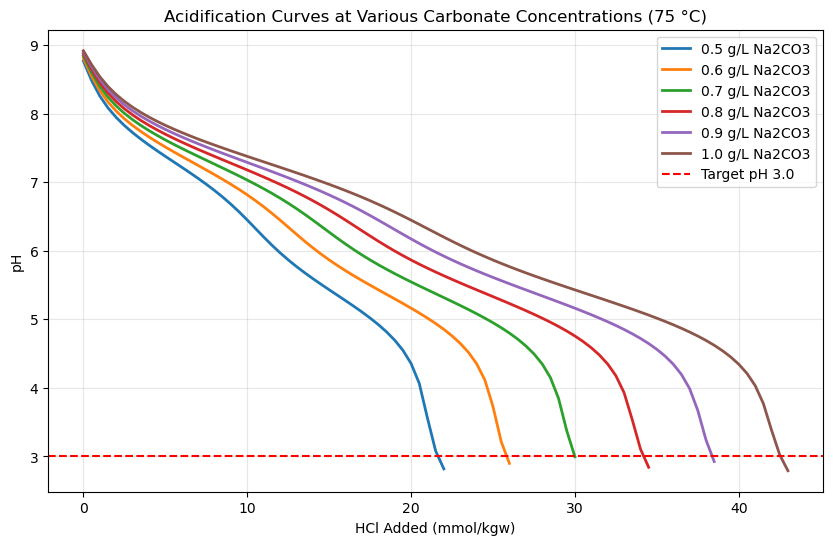

In [12]:
# --- BRINE ACIDIFICATION SIMULATION Varying Carbonate Buffer ---

# 1. Setup the System
db = rkt.PhreeqcDatabase("phreeqc.dat")
system = rkt.ChemicalSystem(db, 
    rkt.AqueousPhase(rkt.speciate("H O Na Cl Ca Mg C")).set(rkt.ActivityModelPitzer())
)

# 2. Define Acid (HCl)
acid = rkt.Material(system)
acid.add("H+", 1.0, "mol")
acid.add("Cl-", 1.0, "mol")

# 3. Carbonate Loop
# Replace numpy arange with a list comprehension
carbonate_gl_values = [x / 10.0 for x in range(5, 11)]
results = {}

print("Starting Titrations across varying carbonate concentrations...")

for carb_gl in carbonate_gl_values:
    # Calculate molality: (g/L) / 105.99 / 0.9
    carb_molality = carb_gl / 105.99 / 0.9
    
    # Define the Base Brine for this iteration
    brine = rkt.Material(system)
    brine.add("H2O", 1.0, "kg")
    brine.add("Na+", 5.513, "mol")
    brine.add("Cl-", 5.513, "mol")
    brine.add("Ca+2", 2.22e-7, "mol")
    brine.add("Mg+2", 9.14e-8, "mol")
    brine.add("OH-", 1e-5, "mol")
    brine.add("Na2CO3", carb_molality, "mol")
    
    hcl_amount = 0.0
    step = 0.0005 # Step of 0.5 mmol
    
    # Equilibrate at standard 75 C, 2 atm
    state_initial = brine.equilibrate(75, "celsius", 2, "atm")
    current_ph = rkt.AqueousProps(state_initial).pH()
    
    x_acid, y_ph = [0.0], [current_ph]
    
    while current_ph > 3.0:
        hcl_amount += step
        mixture = brine + acid(hcl_amount, "mol")
        state = mixture.equilibrate(75, "celsius", 2, "atm")
        current_ph = rkt.AqueousProps(state).pH()
        x_acid.append(hcl_amount * 1000)
        y_ph.append(current_ph)
        
    results[carb_gl] = (x_acid, y_ph)
    
    # Density & Precise Plant Flow Calculation
    props = rkt.ChemicalProps(state)
    brine_density = props.density()
    total_kgw_hr = (50 * brine_density) * (1.0 / brine.mass())
    total_hcl_mol_hr = hcl_amount * total_kgw_hr
    kg_industrial_hcl_hr = (total_hcl_mol_hr * 36.46) / 1000 / 0.33
    
    print(f"\n--- RESULTS ({carb_gl:.1f} g/L Na2CO3) ---")
    print(f"Brine Density: {brine_density:.2f} kg/m3")
    print(f"Acid required: {hcl_amount*1000:.2f} mmol/kgw")
    print(f"Industrial HCl (33%) flow: {kg_industrial_hcl_hr/1.16:.2f} L/hr")

# 4. Plotting
plt.figure(figsize=(10, 6))
for carb_gl in carbonate_gl_values:
    x_acid, y_ph = results[carb_gl]
    plt.plot(x_acid, y_ph, marker='', linewidth=2, label=f"{carb_gl:.1f} g/L Na2CO3")

plt.axhline(y=3.0, color='red', linestyle='--', label="Target pH 3.0")
plt.title("Acidification Curves at Various Carbonate Concentrations (75 °C)")
plt.xlabel("HCl Added (mmol/kgw)")
plt.ylabel("pH")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

<a id="reaktoro-understands-ph-buffering"></a>
## Reaktoro Understands pH Buffering

Now lets compare cell `9` (zero carbonate) with cells `10` & `12` (carbonated brine). One can observe that carbonate is the single biggest sponge for acid in brine. Acid dosage is staggering with a carbonated brine when compared with a zero carbonate system. 

> **⚠️ Important Note**
> Tightly control $CO_3^{2-}$ concentrations in feed brine to reduce acid consumption

A **Buffer** describes the *behavior* of a solution. A buffer is any chemical system that actively resists changes in pH when we add acid or base to it. When using the term **"Carbonate Buffer"** it describes what those carbonate ions are actively *doing* during a titration or acidification process. 

When we add $Na_2CO_3$ to a brine solution, we are adding a huge amount of alkalinity. Before the injected acid (like HCl) can drop the pH of the water down to a target like 3.0, it first has to destroy all of that carbonate in a two-step process:

1.  **First, it converts Carbonate to Bicarbonate:** 
    $$CO_3^{2-} + H^+ \rightarrow HCO_3^-$$
    *(This buffers the pH around 9 down to 6)*

2.  **Then, it converts Bicarbonate to Carbonic Acid / Dissolved $CO_2$:**
    $$HCO_3^- + H^+ \rightarrow H_2CO_3 \rightarrow H_2O + CO_2(aq)$$
    *(This buffers the pH around 6 down to 4)*

Only *after* almost all the carbonate is converted into dissolved $CO_2$ does the pH finally "break" and crash down to the target of 3.0. 


Starting Titration for Carbonate Only down to pH 2.0...


Starting Titration for Carbonate + Sulfate down to pH 2.0...



--- RESULTS: Carbonate Only ---
Brine Density: 1178.95 kg/m3
Acid required: 41.00 mmol/kgw
Industrial HCl (33%) flow: 173.98 L/hr

--- RESULTS: Carbonate + Sulfate ---
Brine Density: 1187.88 kg/m3
Acid required: 47.00 mmol/kgw
Industrial HCl (33%) flow: 199.28 L/hr


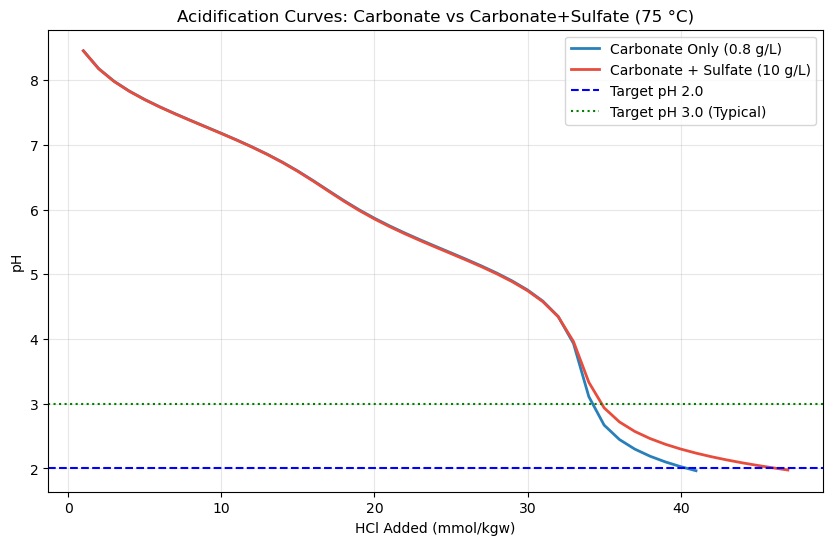

In [13]:
# --- BRINE ACIDIFICATION SIMULATION Carbonate vs Carbonate+Sulfate (Target pH 2.0)---

# 1. Setup the System
db = rkt.PhreeqcDatabase("phreeqc.dat")
system = rkt.ChemicalSystem(db, 
    rkt.AqueousPhase(rkt.speciate("H O Na Cl Ca Mg C S")).set(rkt.ActivityModelPitzer())
)

# 2. Define the Base Brines
# Brine 1: Carbonate only (0.8 g/L Na2CO3)
brine1 = rkt.Material(system)
brine1.add("H2O", 1.0, "kg")
brine1.add("Na+", 5.513, "mol")
brine1.add("Cl-", 5.513, "mol")
brine1.add("Ca+2", 2.22e-7, "mol")
brine1.add("Mg+2", 9.14e-8, "mol")
brine1.add("OH-", 1e-5, "mol")
brine1.add("Na2CO3", 0.008387, "mol")

# Brine 2: Carbonate (0.8 g/L) + Sulfate (10 g/L Na2SO4)
brine2 = rkt.Material(system)
brine2.add("H2O", 1.0, "kg")
brine2.add("Na+", 5.513, "mol")
brine2.add("Cl-", 5.513, "mol")
brine2.add("Ca+2", 2.22e-7, "mol")
brine2.add("Mg+2", 9.14e-8, "mol")
brine2.add("OH-", 1e-5, "mol")
brine2.add("Na2CO3", 0.008387, "mol")
brine2.add("Na2SO4", 0.07822, "mol")

# 3. Define Acid (HCl)
acid = rkt.Material(system)
acid.add("H+", 1.0, "mol")
acid.add("Cl-", 1.0, "mol")

# 4. Titration Functions
def run_titration(brine_material, name):
    hcl_amount = 0.0
    step = 0.001 # 1.0 mmol step for faster execution to pH 2.0
    current_ph = 9.0
    x_acid, y_ph = [], []

    print(f"Starting Titration for {name} down to pH 2.0...")
    while current_ph > 2.0:
        hcl_amount += step
        mixture = brine_material + acid(hcl_amount, "mol")
        state = mixture.equilibrate(75, "celsius", 2, "atm")
        current_ph = rkt.AqueousProps(state).pH()
        x_acid.append(hcl_amount * 1000)
        y_ph.append(current_ph)
        
    return x_acid, y_ph, hcl_amount, state

# Run Titrations
x_acid1, y_ph1, hcl_amount1, state1 = run_titration(brine1, "Carbonate Only")
x_acid2, y_ph2, hcl_amount2, state2 = run_titration(brine2, "Carbonate + Sulfate")

# 5. Density & Precise Plant Flow
def print_results(state, hcl_amount, brine_material, name):
    props = rkt.ChemicalProps(state)
    brine_density = props.density()
    total_kgw_hr = (50 * brine_density) * (1.0 / brine_material.mass())
    total_hcl_mol_hr = hcl_amount * total_kgw_hr
    kg_industrial_hcl_hr = (total_hcl_mol_hr * 36.46) / 1000 / 0.33
    print(f"\n--- RESULTS: {name} ---")
    print(f"Brine Density: {brine_density:.2f} kg/m3")
    print(f"Acid required: {hcl_amount*1000:.2f} mmol/kgw")
    print(f"Industrial HCl (33%) flow: {kg_industrial_hcl_hr/1.16:.2f} L/hr")

print_results(state1, hcl_amount1, brine1, "Carbonate Only")
print_results(state2, hcl_amount2, brine2, "Carbonate + Sulfate")

# 6. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_acid1, y_ph1, marker='', color='#2980b9', linewidth=2, label="Carbonate Only (0.8 g/L)")
plt.plot(x_acid2, y_ph2, marker='', color='#e74c3c', linewidth=2, label="Carbonate + Sulfate (10 g/L)")

plt.axhline(y=2.0, color='blue', linestyle='--', label="Target pH 2.0")
plt.axhline(y=3.0, color='green', linestyle=':', label="Target pH 3.0 (Typical)")

plt.title("Acidification Curves: Carbonate vs Carbonate+Sulfate (75 °C)")
plt.xlabel("HCl Added (mmol/kgw)")
plt.ylabel("pH")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

<a id="simulating-multiple-impurities-impact-on-acid-consumption"></a>
## Simulating Multiple Impurities Impact on Acid Consumption

Understanding the concept of $pK_a$ is crucial for chemical engineers working in waste water treatment, environmental safety & chloralkali industry. The concept is visualised in a way that relates to process engineering operations.

The easiest way to visualize a conjugate base (like $CO_3^{2-}$ or $SO_4^{2-}$) is as a **magnet for protons ($H^+$)**.
*   **The $pK_a$ is the "Grip Strength"** of that magnet.
*   **The $pH$ is the "Crowd"** of free protons swarming around the magnet. 

<a id="pk_a-is-for-ions-only"></a>
### $pK_a$ is for ions only

**Salts like $Na_2CO_3$ (Sodium Carbonate) or $Na_2SO_4$ (Sodium Sulfate) do not have their own $pK_a$ values.** Instead, the $pK_a$ values belong to their corresponding **conjugate acids** (Carbonic Acid and Sulfuric Acid). When you dissolve a salt in water, it breaks into ions (like $Na^+$ and $CO_3^{2-}$). The $Na^+$ does nothing to the pH, but the $CO_3^{2-}$ interacts with the water based on the $pK_a$ of its parent acid.

**The Sulfate ion ($SO_4^{2-}$) is exactly the same, no matter where it came from.** Whether that $SO_4^{2-}$ ion originally came from $Na_2SO_4$, $K_2SO_4$, or $H_2SO_4$, once it is floating in the water, it follows the exact same thermodynamic rules.

<a id="carbonate-system-carbonic-acid-h_2co_3"></a>
#### Carbonate System (Carbonic Acid, $H_2CO_3$)
**Reference:** [Wikipedia: Carbonic Acid (Acidity section)](https://en.wikipedia.org/wiki/Carbonic_acid#Acidity)

It requires two distinct half-reactions to fully decompose, and each step has its own unique $pK_a$:

*   **Step 1 ($pK_{a2}$ = 10.33):** The transition between Carbonate ($CO_3^{2-}$) and Bicarbonate ($HCO_3^-$).
*   **Step 2 ($pK_{a1}$ = 6.35):** The transition between Bicarbonate ($HCO_3^-$) and Carbonic Acid / Dissolved $CO_2$ ($H_2CO_3$).

*Note: The 6.35 value is the "apparent" $pK_a$ commonly used in engineering, which accounts for the fact that most $H_2CO_3$ immediately turns into dissolved $CO_2$ gas.*

<a id="sulfate-system-sulfuric-acid-h_2so_4"></a>
#### Sulfate System (Sulfuric Acid, $H_2SO_4$)
**Reference:** [Wikipedia: Sulfuric Acid (Properties section)](https://en.wikipedia.org/wiki/Sulfuric_acid#Chemical_properties)

Like Carbonate, Sulfate also comes from a diprotic acid, meaning it also has two half-reactions. However, Sulfuric acid is a *strong acid*, which completely changes the numbers:

*   **Step 1 ($pK_{a1}$ ≈ -3.0):** The transition between Sulfuric Acid ($H_2SO_4$) and Bisulfate ($HSO_4^-$). This value is negative, meaning the first proton falls off immediately in water. You will never encounter intact $H_2SO_4$ in your brine.
*   **Step 2 ($pK_{a2}$ = 1.99):** The transition between Bisulfate ($HSO_4^-$) and Sulfate ($SO_4^{2-}$).


> **⚠️ Important Note**
> If the $pK_a$ is high (like Carbonate at 10.3), the magnet is incredibly strong. It will aggressively pull protons out of the water. If the $pK_a$ is low (like Sulfate at 2.0), the magnet is very weak; it won't grab a proton unless the water is absolutely swarming with them (a low pH environment).

<a id="henderson-hasselbalch-equation"></a>
## Henderson-Hasselbalch Equation
There is a direct and elegant mathematical relationship between $pH$ and $pK_a$ that completely dictates whether a chemical species acts as a buffer or is "destroyed" (fully protonated/deprotonated).

This relationship is defined by the **Henderson-Hasselbalch Equation**:

$$pH = pK_a + \log_{10}\left(\frac{[\text{Conjugate Base}]}{[\text{Acid}]}\right)$$

We can rearrange this equation to solve for the exact ratio of the two chemical species present at any given pH:

$$\frac{[\text{Conjugate Base}]}{[\text{Acid}]} = 10^{(pH - pK_a)}$$

This rearranged formula is the key to understanding *why* the carbonate buffer is fully destroyed at pH 3.0. Let's look at the math for the two dissociation steps of Carbonate.

<a id="why-carbonate-is-a-sponge-for-acid"></a>
### Why Carbonate is a sponge for acid
<a id="step-1-carbonate-co_32--to-bicarbonate-hco_3-"></a>
#### Step 1: Carbonate ($CO_3^{2-}$) to Bicarbonate ($HCO_3^-$)
*   **$pK_{a1}$** $\approx 10.3$
*   **Target pH:** $3.0$

Let's plug these values into the rearranged equation to find the ratio of Carbonate to Bicarbonate remaining in the brine at pH 3.0:

$$\frac{[CO_3^{2-}]}{[HCO_3^-]} = 10^{(3.0 - 10.3)} = 10^{-7.3} = \mathbf{0.00000005}$$

**The Mathematical Result:** At pH 3.0, for every 100 million Bicarbonate molecules, there are only 5 Carbonate molecules left. The Carbonate has been completely annihilated and converted into Bicarbonate. It consumed its first molecule of HCl.

<a id="step-2-bicarbonate-hco_3--to-carbonic-acid-h_2co_3"></a>
#### Step 2: Bicarbonate ($HCO_3^-$) to Carbonic Acid ($H_2CO_3$)
*   **$pK_{a2}$** $\approx 6.3$
*   **Target pH:** $3.0$

Now let's look at the second step. How much of that Bicarbonate survives the journey down to pH 3.0?

$$\frac{[HCO_3^-]}{[H_2CO_3]} = 10^{(3.0 - 6.3)} = 10^{-3.3} = \mathbf{0.0005}$$

**The Mathematical Result:** At pH 3.0, the ratio is $0.0005$. This means that **99.95%** of the Bicarbonate has been forcefully converted into Carbonic Acid (which immediately turns into dissolved $CO_2$ and water). It has consumed its second molecule of HCl.

<a id="why-sulphate-didnt-consumed-acid"></a>
### Why Sulphate didn't consumed acid
**Sulfate ($SO_4^{2-}$):** Sulfate is the conjugate base of Bisulfate ($HSO_4^-$), which is a weak acid with a $pK_a$ of roughly **2.0**.
*   **$pK_a$** $\approx 2$
*   **Target pH:** $3.0$

$$pH = pK_a + \log_{10}\left(\frac{[SO_4^{2-}]}{[HSO_4^-]}\right)$$
$$3.0 = 2.0 + \log_{10}\left(\frac{[SO_4^{2-}]}{[HSO_4^-]}\right)$$
$$\frac{[SO_4^{2-}]}{[HSO_4^-]} \approx 10$$

This means that at pH 3.0, **roughly 9% to 10% of the sulfate will have converted into bisulfate ($HSO_4^-$)**. 
If you have 10 g/L of $Na_2SO_4$ (about 70 mmol/L of total sulfate), only about **6 to 7 mmol/L** of it will actually consume a proton from your HCl to reach pH 3.0. 

Compare this to the 0.8 g/L of $Na_2CO_3$ (only ~7.5 mmol/L), which consumed ~15 mmol/L of HCl. Even though 10 g/L is a massive physical amount of sulfate salt, its chemical acid demand is relatively small because you aren't dropping the pH low enough to fully protonate it.

<a id="first-engineering-rule-of-thumb"></a>
### First Engineering Rule of Thumb
The math reveals a very simple rule of thumb for chemical engineers looking at titration and buffering:

If the $pH$ is **2 full units below the $pK_a$**, the species is essentially gone (**>99% converted**).

*   At pH 8.3 (2 units below 10.3), almost all the $CO_3^{2-}$ is gone.
*   At pH 4.3 (2 units below 6.3), almost all the $HCO_3^-$ is gone.

Because your target pH of **3.0** is far, far below both of those $pK_a$ values (it is 7.3 units below 10.3, and 3.3 units below 6.3), the math guarantees that the entire carbonate buffer has been chemically neutralized, requiring a massive and predictable amount of acid to accomplish.

<a id="engineering-danger-of-having-ph-close-to-pk_a"></a>
### Engineering Danger of having $pH$ close to $pK_a$
While 10 g/L of sulfate only requires a mild increase in acid to reach **pH 3.0**, it creates a massive "acid trap" if the plant operators decide to lower the setpoint. If the DCS target is lowered from pH 3.0 down to **pH 2.0**, that 10 g/L of sulfate will suddenly sit right at its $pK_a$, acting as a massive 50% buffer. Acid consumption would absolutely skyrocket, requiring an enormous amount of HCl to push the pH any lower. This is shown by the rightward shift of red curve after pH 3.0

<a id="second-engineering-rule-of-thumb"></a>
### Second Engineering Rule of Thumb

$pK_a$ is simply the **50/50 Tipping Point**.

$$pH = pK_a \rightarrow \text{Exactly 50\% Acid and 50\% Conjugate Base}$$

If an operator knows that the $pK_a$ of Sulfate is 2.0, they immediately know that if the DCS is set to pH 2.0, exactly half of the 10 g/L of sulfate in the brine is acting as acid ($HSO_4^-$) and half is acting as base ($SO_4^{2-}$). This teaches them to fear the $pK_a$ zones. If the plant operates near a $pK_a$ point, the system is highly buffered and incredibly hard to control because small fluctuations in feed composition will completely swing the acid demand.

<a id="analyzing-the-curves"></a>
### Analyzing the Curves

Titration curve is like a ball rolling down a set of stairs.
*   The flat parts (the steps or "shelves") are the **Buffering Zones**.
*   The vertical drops are the **Dead Zones** where no buffering happens.

The $pK_a$ value tells you **exactly where the shelf is vertically located on the y-axis (pH).**
*   Carbonate builds a massive shelf at pH 10.3 and another at pH 6.3.
*   Sulfate builds a massive shelf at pH 2.0.

Check the curves at cell `10` which explains above theoretical concepts:
1. Look at the Y-axis (pH) and visually trace a horizontal line across the graph at exactly **pH 6.3**. This flat region is the **"6.3 Shelf"** (the Sponge Zone), all of the curves lose their steepness and flatten out into a long, gentle slope. Notice that the curve travels horizontally for a massive distance (consuming around 20–25 mmol/kgw of acid) while barely dropping vertically. This is visual proof that the Bicarbonate ($HCO_3^-$) is aggressively "gripping" the protons at its $pK_a$, actively resisting a drop in pH.
2. Look what happens to the curves after they pass pH 4.0. This is the **"Dead Zone"**. Recall *First Engineering Rule of Thumb*. By the time the brine reaches pH 4.3 (two units below 6.3), the carbonate sponge is completely gone. Because there is no more buffer left to grab the protons, every extra drop of HCl causes the pH to crash instantly.

<a id="revisiting-ph-temperature-dependance"></a>
#### Revisiting pH Temperature Dependance

The $pK_a$ value is not just a static number in a textbook; it is a thermodynamic property that changes with temperature! If they look closely at the graph at cell `10`, the "shelf" for the hot 75 °C brine is physically located slightly lower on the Y-axis than the shelf for the cold 25 °C brine. This is more apparent if we check zoomed in graph at cell `11`
    * **If the Target is in the Buffer Zone (e.g., Target pH = 7.0):** We need LESS acid at 75 °C. This is because the $pK_a$ shelf has shifted downwards, and the hot water is naturally helping us by generating more of its own $H^+$ background noise (the $K_w$ effect).
    * **If the Target is in the Dead Zone (e.g., Target pH = 3.0):**  We actually need MORE acid at 75 °C. This is where the **Temperature Pivot** occurs as was explained before. As we keep adding acid and push the ball off the shelf into the "Dead Zone" (pH < 4.0), the curves **cross over each other**. Hot 75 °C brine suppresses the activity coefficient ($\gamma_{H^+}$). The free protons become "lazy."

Now lets discuss plot at cell `13` and effect of sulphate impurity in brine on acid dosage:

1. **Between pH 9.0 and pH 4.0:** The two curves (blue for Carbonate-only, red for Carbonate + Sulfate) are virtually identical and lie directly on top of each other. The Sulfate hasn't entered its buffering zone yet, so both solutions require exactly the same amount of acid to crush the Carbonate buffer.
2. **Between pH 4.0 and pH 3.0:** The curve will start to "drag" or flatten out slightly. The red curve begins to diverge slightly to the right. The $SO_4^{2-} \rightarrow HSO_4^-$ reaction has started to weakly soak up some protons.
3. **Between pH 3.0 and pH 2.0 (The Danger Zone):** The divergence becomes massive. The blue Carbonate-only curve crashes relatively straight down, hitting pH 2.0 at ~41 mmol/kgw. In contrast, the red curve hits a "shelf" and drags heavily to the right as it crashes into the Sulfate $pK_a$ (~2.0), demanding an extra 6 mmol/kgw (totaling 47 mmol/kgw) to reach the exact same target!
